# Laboratorio 4 - Tasks 1, 2 y 3: Modelo de movilidad urbana basado en agentes

El modelo representa 150 personas que se desplazan en una cuadrícula urbana de $20\times20$. Se implementan dos tipos de agentes: `CommutterAgent` (nombre conservado como aparece en la consigna) y `VehicleAgent`. La solución se basa en el ciclo de vida visto: **inicialización $\rightarrow$ activación $\rightarrow$ comunicación/movilidad $\rightarrow$ eliminación**.

> **Reproducibilidad.** se utiliza la clase `RandomActivation`, disponible en Mesa 2.x. Por eso este cuaderno fija `mesa==2.4.0`. Si no está instalada, descomente y ejecute una sola vez la línea de instalación de la siguiente celda y reinicie el kernel.

## Infraestructura compartida (Tasks 1.1-1.2) 

Infraestructura común del modelo, usada por las Tasks 1.1, 1.2 y 2. Esta celda importa Mesa y fija `RandomActivation` (scheduling, Task 1.1.c) y `MultiGrid` (cuadrícula donde coexisten persona y vehículo, Task 1.2).

In [1]:
from collections import Counter
import warnings

import matplotlib.pyplot as plt
warnings.filterwarnings("ignore", message="IProgress not found.*")
import mesa
import numpy as np
# S7 - Agent Based Modelling P1 - slide 3
from mesa import Agent, Model
# S8 - Agent Based Modeling P2 - slide 6
# S8 - Agent Based Modeling P2 - slide 7
from mesa.space import MultiGrid
# S8 - Agent Based Modeling P2 - slide 5
from mesa.time import RandomActivation

print(f"Mesa: {mesa.__version__}")
assert mesa.__version__.startswith("2."), (
    "La consigna usa RandomActivation de Mesa 2.x. Instale mesa==2.4.0."
)

Mesa: 2.4.0


## Parámetros globales (Task 1.1.a) y utilidad de distancia (Task 1.2.a)

Se fijan $\mu$ y $\Sigma$ de la normal multivariada indicada en la consigna (Task 1.1.a) y se define la distancia Manhattan, usada tanto para ubicar el destino de cada agente como para la regla de movimiento por celda (Task 1.2.a).

In [2]:
# Parámetros de la normal multivariada indicados en la consigna.
# S8 - Agent Based Modeling P2 - slide 12
MU = np.array([8500.0, 6.5])
SIGMA = np.array([
    [4_000_000.0, -800.0],
    [-800.0, 4.0],
])


# S8 - Agent Based Modeling P2 - slide 7
def manhattan(a, b):
    # Distancia Manhattan entre dos celdas (x, y).
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

## Definición de agentes: VehicleAgent y CommutterAgent

Esta celda concentra el comportamiento de ambos tipos de agente a lo largo de su ciclo de vida (inicialización, activación, comunicación, eliminación), la elección de modo de transporte determinista (Task 1.1.b, método `choose_transport`), el movimiento por el camino Manhattan más corto con espera si la celda está ocupada (Task 1.2.a, método `_target_cell`/`step`) y la eliminación del agente y su vehículo al llegar al destino (Task 1.2.c, método `_remove_from_system`).

In [3]:
# S7 - Agent Based Modelling P1 - slide 3
class VehicleAgent(Agent):
    # Vehículo asociado a una persona que eligió automóvil.

    def __init__(self, unique_id, model, owner):
        super().__init__(unique_id, model)
        self.owner = owner
        self.active = True

# S8 - Agent Based Modeling P2 - slide 4
    def step(self):
        # El scheduler activa también a los VehicleAgent. Su posición la
        # actualiza el conductor para mantener persona y vehículo sincronizados.
        self.model.activation_order.append(self.unique_id)


# S7 - Agent Based Modelling P1 - slide 3
class CommutterAgent(Agent):
    # Persona que se desplaza diariamente hacia una celda destino.

    def __init__(self, unique_id, model, ingreso, distancia, destino):
        super().__init__(unique_id, model)
        self.ingreso = float(ingreso)          # quetzales/mes
        self.distancia = float(distancia)      # km
        self.destino = destino
        self.modo = None
        self.congestion_percibida = None
        self.vehicle = None
        self.arrived = False

# S7 - Agent Based Modelling P1 - slide 6
# S8 - Agent Based Modeling P2 - slide 6
    def choose_transport(self):
        # Task 1.1.b: regla determinista indicada en la consigna.
        if self.pos is None:
            self.congestion_percibida = 0
        else:
            x, y = self.pos
            self.congestion_percibida = int(self.model.congestion_map[x, y])

        if self.distancia <= 3 and self.model.policy_active:
            self.modo = "bicicleta"
        else:
            self.modo = "automovil"
        return self.modo

# S8 - Agent Based Modeling P2 - slide 7
    def _target_cell(self):
        # Elige una celda vecina que reduce en uno la distancia Manhattan.
        if self.pos == self.destino:
            return None

        x, y = self.pos
        dx, dy = self.destino
        candidates = []

        if x != dx:
            candidates.append((x + (1 if dx > x else -1), y))
        if y != dy:
            candidates.append((x, y + (1 if dy > y else -1)))

        # Si hay dos caminos mínimos, la elección evita un sesgo fijo hacia x o y.
        return self.model.random.choice(candidates)

# S8 - Agent Based Modeling P2 - slide 6
    def _occupied_by_other(self, cell):
        occupants = self.model.grid.get_cell_list_contents([cell])
        return any(
            agent is not self and agent is not self.vehicle
            for agent in occupants
        )

# S8 - Agent Based Modeling P2 - slide 4
    def _remove_from_system(self):
        # Task 1.2.c: elimina al agente y su vehículo al llegar.
        if self.vehicle is not None and self.vehicle.active:
            if self.vehicle in self.model.schedule.agents:
                self.model.schedule.remove(self.vehicle)
            if self.vehicle.pos is not None:
                self.model.grid.remove_agent(self.vehicle)
            self.vehicle.active = False

        # Llamadas requeridas explícitamente por la consigna.
        self.model.schedule.remove(self)
        self.model.grid.remove_agent(self)
        self.arrived = True

# S8 - Agent Based Modeling P2 - slide 4
# S8 - Agent Based Modeling P2 - slide 7
    def step(self):
        # Task 1.2.a: avanza una celda por un camino Manhattan mínimo.
        self.model.activation_order.append(self.unique_id)

        if self.modo is None:
            self.choose_transport()

        if self.pos == self.destino:
            if self.model.remove_on_arrival:
                self._remove_from_system()
            return

        target = self._target_cell()
        if target is not None and not self._occupied_by_other(target):
            self.model.grid.move_agent(self, target)
            if self.vehicle is not None and self.vehicle.active:
                self.model.grid.move_agent(self.vehicle, target)

        # Tanto si se movió como si esperó, se verifica la condición terminal.
        if self.pos == self.destino and self.model.remove_on_arrival:
            self._remove_from_system()

## Definición del modelo UrbanMobilityModel

El modelo integra la infraestructura de scheduling y de entorno, crea la cuadrícula `MultiGrid` de 20x20 y el scheduler `RandomActivation` (Task 1.1.c), genera los 150 `CommutterAgent` con atributos correlacionados mediante la descomposición de Cholesky de $\Sigma$ (Task 1.1.a), y mantiene `congestion_map`, la variable de entorno que se actualiza al final de cada paso y funciona como comunicación por entorno (Task 1.2.b).

In [4]:
class UrbanMobilityModel(Model):
    # Modelo ABM de movilidad en una cuadrícula urbana de 20 x 20.

    def __init__(
        self,
        N=150,
        policy_active=False,
        width=20,
        height=20,
        seed=None,
        remove_on_arrival=True,
    ):
        super().__init__(seed=seed)
        if N > width * height:
            raise ValueError("N no puede exceder el número de celdas iniciales.")

        self.N = N
        self.policy_active = policy_active
        self.width = width
        self.height = height
        self.remove_on_arrival = remove_on_arrival

# S8 - Agent Based Modeling P2 - slide 6
# S8 - Agent Based Modeling P2 - slide 7
        self.grid = MultiGrid(width, height, torus=False)
# S8 - Agent Based Modeling P2 - slide 5
        self.schedule = RandomActivation(self)
        self.np_rng = np.random.default_rng(seed)
        self.congestion_map = np.zeros((width, height), dtype=int)
        self.activation_order = []
        self.active_history = []

# S8 - Agent Based Modeling P2 - slide 12
        # X = mu + Z L^T, con Z ~ N(0, I) y Sigma = L L^T.
        self.cholesky = np.linalg.cholesky(SIGMA)
        z = self.np_rng.standard_normal((N, 2))
        self.initial_attributes = MU + z @ self.cholesky.T

# S7 - Agent Based Modelling P1 - slide 5
# S8 - Agent Based Modeling P2 - slide 4
        # Posiciones iniciales distintas para las personas. El vehículo de
        # una persona se coloca en la misma celda, permitido por MultiGrid.
        cells = [(x, y) for x in range(width) for y in range(height)]
        origins = self.random.sample(cells, k=N)
        self.commutters = []

        for i, ((income, distance), origin) in enumerate(
            zip(self.initial_attributes, origins)
        ):
            destination = self._destination_at_distance(origin, distance)
            commuter = CommutterAgent(
                unique_id=f"C{i:03d}",
                model=self,
                ingreso=income,
                distancia=distance,
                destino=destination,
            )
            self.commutters.append(commuter)
            self.grid.place_agent(commuter, origin)
            self.schedule.add(commuter)

# S7 - Agent Based Modelling P1 - slide 6
        # La decisión de transporte se toma con la regla de Task 1.1.b.
        # Se crea un VehicleAgent solamente para quienes usan automóvil.
        for i, commuter in enumerate(self.commutters):
            commuter.choose_transport()
            if commuter.modo == "automovil":
                vehicle = VehicleAgent(f"V{i:03d}", self, commuter)
                commuter.vehicle = vehicle
                self.grid.place_agent(vehicle, commuter.pos)
                self.schedule.add(vehicle)

        self.update_congestion_map()
        self.active_history.append(self.schedule.get_agent_count())

# S8 - Agent Based Modeling P2 - slide 7
    def _destination_at_distance(self, origin, distance_km):
        # Asigna un destino cuya distancia espacial aproxima los km muestreados.
        target_steps = int(np.clip(round(distance_km), 0, self.width + self.height - 2))
        cells = [(x, y) for x in range(self.width) for y in range(self.height)]
        exact = [cell for cell in cells if manhattan(origin, cell) == target_steps]

        if exact:
            return self.random.choice(exact)

        # En un borde puede no existir una celda a una distancia muy grande.
        best_error = min(abs(manhattan(origin, cell) - target_steps) for cell in cells)
        closest = [
            cell
            for cell in cells
            if abs(manhattan(origin, cell) - target_steps) == best_error
        ]
        return self.random.choice(closest)

# S8 - Agent Based Modeling P2 - slide 6
    def update_congestion_map(self):
        # Task 1.2.b: cuenta VehicleAgent activos al final del paso.
        self.congestion_map.fill(0)
        for agent in self.schedule.agents:
            if isinstance(agent, VehicleAgent) and agent.active and agent.pos is not None:
                x, y = agent.pos
                self.congestion_map[x, y] += 1

    def active_commutters(self):
        return [
            agent
            for agent in self.schedule.agents
            if isinstance(agent, CommutterAgent)
        ]

# S8 - Agent Based Modeling P2 - slide 4
# S8 - Agent Based Modeling P2 - slide 5
# S8 - Agent Based Modeling P2 - slide 6
    def step(self):
        self.activation_order = []
        self.schedule.step()
        # Se actualiza después de todas las activaciones: comunicación por entorno.
        self.update_congestion_map()
        self.active_history.append(self.schedule.get_agent_count())
        self.running = len(self.active_commutters()) > 0

## Task 1.1.a - Inicialización multivariada mediante Cholesky

Matriz L de Cholesky:
[[ 2.00000000e+03  0.00000000e+00]
 [-4.00000000e-01  1.95959179e+00]]
Correlación teórica: -0.2000
Correlación muestral: -0.1388
Verificación del signo: PASA


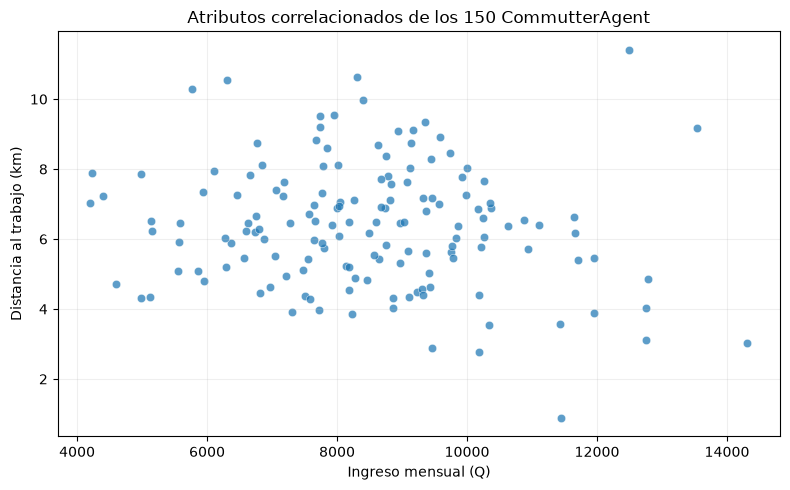

In [5]:
# S7 - Agent Based Modelling P1 - slide 5
# S8 - Agent Based Modeling P2 - slide 12
# S8 - Agent Based Modeling P2 - slide 13
model = UrbanMobilityModel(N=150, policy_active=True, seed=42)
incomes = model.initial_attributes[:, 0]
distances = model.initial_attributes[:, 1]

sample_correlation = np.corrcoef(incomes, distances)[0, 1]
theoretical_correlation = SIGMA[0, 1] / np.sqrt(SIGMA[0, 0] * SIGMA[1, 1])

print("Matriz L de Cholesky:")
print(model.cholesky)
print(f"Correlación teórica: {theoretical_correlation:.4f}")
print(f"Correlación muestral: {sample_correlation:.4f}")
print(
    "Verificación del signo:",
    "PASA" if np.sign(sample_correlation) == np.sign(SIGMA[0, 1]) else "FALLA",
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(incomes, distances, alpha=0.72, edgecolor="white", linewidth=0.4)
ax.set(
    title="Atributos correlacionados de los 150 CommutterAgent",
    xlabel="Ingreso mensual (Q)",
    ylabel="Distancia al trabajo (km)",
)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Task 1.2 - Movilidad, comunicación por entorno y eliminación

**Movilidad.** En cada activación, `CommutterAgent.step()` construye las celdas adyacentes que reducen la distancia Manhattan exactamente en uno. Si hay dos alternativas mínimas, elige una al azar. Si la celda objetivo contiene otro agente, espera; de lo contrario, se mueve una celda. Cuando conduce, su `VehicleAgent` se desplaza con él.

**Comunicación por entorno.** `congestion_map[x, y]` contiene el número de `VehicleAgent` activos en la celda $(x,y)$. Se recalcula al final del paso, después de todas las activaciones. `choose_transport()` lee la congestión local y la guarda como percepción; la regla obligatoria sigue dependiendo solo de distancia y política, pero la percepción queda disponible para la extensión probabilística propuesta.

**Eliminación.** Al llegar se ejecutan las llamadas requeridas a `schedule.remove` y `grid.remove_agent`; también se elimina el vehículo asociado. Si se omitiera esta etapa, los agentes terminados seguirían siendo activados, ocuparían celdas y bloquearían rutas.

In [6]:
# S8 - Agent Based Modeling P2 - slide 4
# S8 - Agent Based Modeling P2 - slide 6
# S8 - Agent Based Modeling P2 - slide 7
# Evidencia funcional de Task 1.2.
demo = UrbanMobilityModel(N=150, policy_active=True, seed=42)
initial_positions = {agent.unique_id: agent.pos for agent in demo.active_commutters()}
vehicles_before = int(demo.congestion_map.sum())

demo.step()

active_after = demo.active_commutters()
moved_or_arrived = sum(
    agent.arrived or agent.pos != initial_positions[agent.unique_id]
    for agent in demo.commutters
)
active_vehicles = sum(
    isinstance(agent, VehicleAgent) for agent in demo.schedule.agents
)

print(f"Forma de congestion_map: {demo.congestion_map.shape}")
print(f"Vehículos antes del paso: {vehicles_before}")
print(f"Vehículos activos después del paso: {active_vehicles}")
print(f"Suma de congestion_map después del paso: {demo.congestion_map.sum()}")
print(f"Personas que se movieron o llegaron en el paso: {moved_or_arrived}")
print(
    "Consistencia mapa-vehículos:",
    "PASA" if demo.congestion_map.sum() == active_vehicles else "FALLA",
)

Forma de congestion_map: (20, 20)
Vehículos antes del paso: 147
Vehículos activos después del paso: 147
Suma de congestion_map después del paso: 147
Personas que se movieron o llegaron en el paso: 98
Consistencia mapa-vehículos: PASA


## Task 1.3 - Verificación de la implementación

Las pruebas siguientes separan tres riesgos: 
- orden de activación
- distribución inicial incorrecta 
- eliminación defectuosa. 

Para la prueba del scheduler se desactiva temporalmente la eliminación (`remove_on_arrival=False`); así se verifica el mismo conjunto de agentes durante tres pasos sin mezclar el resultado con el ciclo de vida terminal. La configuración normal mantiene la eliminación activada.

In [7]:
# S8 - Agent Based Modeling P2 - slide 5
# S8 - Agent Based Modeling P2 - slide 13
# Task 1.3.a - Prueba de scheduler.
scheduler_test = UrbanMobilityModel(
    N=150,
    policy_active=False,
    seed=2026,
    remove_on_arrival=False,
)

activation_orders = []
exactly_once = []

for step_number in range(1, 4):
    ids_before = [agent.unique_id for agent in scheduler_test.schedule.agents]
    scheduler_test.step()
    order = scheduler_test.activation_order.copy()
    activation_orders.append(order)

    step_passes = Counter(order) == Counter(ids_before)
    exactly_once.append(step_passes)
    print(f"Paso {step_number} ({len(order)} activaciones):")
    print(", ".join(order))
    print("Cada agente exactamente una vez:", "PASA" if step_passes else "FALLA")
    print()

order_changes = all(
    activation_orders[i] != activation_orders[i - 1]
    for i in range(1, len(activation_orders))
)
scheduler_passes = all(exactly_once) and order_changes

print("El orden cambia entre pasos:", "PASA" if order_changes else "FALLA")
print("RESULTADO PRUEBA DE SCHEDULER:", "PASA" if scheduler_passes else "FALLA")

Paso 1 (300 activaciones):
C063, V047, C112, V094, V061, V093, V071, C100, C025, C064, C047, V039, V024, V147, V072, C113, C043, C057, V088, V014, C132, C147, C055, V006, C026, V005, C116, C118, V122, V127, C088, V125, V021, C052, V064, V026, V112, V050, V069, C083, V044, V035, V009, C016, C078, C060, V087, C114, V070, C071, V095, C008, C015, V030, V004, V018, C034, C099, V115, V107, V042, C023, C053, C000, V007, V053, C086, C097, V031, V023, C003, C137, C129, V118, V013, V141, V052, C134, V058, C127, C123, V022, C036, C126, C085, V090, V099, C024, V003, C075, C109, V097, V149, V081, C042, V124, C125, C018, C010, C013, V037, C020, V103, V134, C103, C066, V000, C139, V077, V096, C073, C136, V091, C089, C119, V102, C027, C068, V113, C115, C012, V142, C145, C017, C033, C093, C069, C146, V085, C021, C044, V020, C104, V065, C001, C124, C039, C105, C040, V119, C079, C121, C140, C144, C117, V114, C095, C051, V043, V143, V076, C059, C092, C102, C038, C130, V051, V063, V123, V120, V040, C002, V

In [9]:
# S8 - Agent Based Modeling P2 - slide 12
# S8 - Agent Based Modeling P2 - slide 13
# Task 1.3.b - Prueba de inicialización.
initialization_test = UrbanMobilityModel(N=150, policy_active=True, seed=42)
attributes = initialization_test.initial_attributes
sample_means = attributes.mean(axis=0)
sample_stds = attributes.std(axis=0, ddof=1)
theoretical_stds = np.sqrt(np.diag(SIGMA))

# Para las medias: margen de tres errores estándar de la media.
mean_tolerances = 3 * theoretical_stds / np.sqrt(initialization_test.N)
mean_ok = np.abs(sample_means - MU) <= mean_tolerances

# Para las desviaciones: margen relativo explícito del 20%.
std_relative_errors = np.abs(sample_stds - theoretical_stds) / theoretical_stds
std_ok = std_relative_errors <= 0.20

labels = ["Ingreso (Q/mes)", "Distancia (km)"]
for i, label in enumerate(labels):
    print(label)
    print(f"  media teórica = {MU[i]:.4f}")
    print(f"  media muestral  = {sample_means[i]:.4f}")
    print(f"  tolerancia media (3 EE) = ±{mean_tolerances[i]:.4f}")
    print(f"  desviación teórica = {theoretical_stds[i]:.4f}")
    print(f"  desviación muestral  = {sample_stds[i]:.4f}")
    print(f"  error relativo de la desviación = {std_relative_errors[i]:.2%}")

initialization_passes = bool(np.all(mean_ok) and np.all(std_ok))
print(
    "RESULTADO PRUEBA DE INICIALIZACIÓN:",
    "PASA" if initialization_passes else "FALLA",
)

Ingreso (Q/mes)
  media teórica = 8500.0000
  media muestral  = 8462.2889
  tolerancia media (3 EE) = ±489.8979
  desviación teórica = 2000.0000
  desviación muestral  = 1937.7008
  error relativo de la desviación = 3.11%
Distancia (km)
  media teórica = 6.5000
  media muestral  = 6.3835
  tolerancia media (3 EE) = ±0.4899
  desviación teórica = 2.0000
  desviación muestral  = 1.7605
  error relativo de la desviación = 11.97%
RESULTADO PRUEBA DE INICIALIZACIÓN: PASA


In [10]:
# S8 - Agent Based Modeling P2 - slide 4
# S8 - Agent Based Modeling P2 - slide 13
# Task 1.3.c - Prueba de conservación/eliminación.
conservation_test = UrbanMobilityModel(
    N=150,
    policy_active=False,
    seed=17,
    remove_on_arrival=True,
)

active_counts = [conservation_test.schedule.get_agent_count()]
for _ in range(50):
    if not conservation_test.running:
        break
    conservation_test.step()
    active_counts.append(conservation_test.schedule.get_agent_count())

differences = np.diff(active_counts)
non_increasing = bool(np.all(differences <= 0))
at_least_one_removal = bool(np.any(differences < 0))
conservation_passes = non_increasing and at_least_one_removal

print("Agentes activos por paso:")
print(active_counts)
print("Secuencia monótona no creciente:", "PASA" if non_increasing else "FALLA")
print("Se observó al menos una eliminación:", "PASA" if at_least_one_removal else "FALLA")
print(
    "RESULTADO PRUEBA DE CONSERVACIÓN:",
    "PASA" if conservation_passes else "FALLA",
)

Agentes activos por paso:
[300, 298, 294, 284, 282, 274, 270, 256, 240, 226, 216, 208, 204, 196, 190, 190, 186, 186, 186, 186, 186, 186, 186, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184, 184]
Secuencia monótona no creciente: PASA
Se observó al menos una eliminación: PASA
RESULTADO PRUEBA DE CONSERVACIÓN: PASA


In [11]:
# S8 - Agent Based Modeling P2 - slide 13
task_1_results = {
    "1.3.a Scheduler": scheduler_passes,
    "1.3.b Inicialización": initialization_passes,
    "1.3.c Conservación": conservation_passes,
}

print("RESUMEN TASK 1")
for test_name, passed in task_1_results.items():
    print(f"{test_name}: {'PASA' if passed else 'FALLA'}")

assert all(task_1_results.values()), "Existe al menos una prueba fallida; revise la evidencia."

RESUMEN TASK 1
1.3.a Scheduler: PASA
1.3.b Inicialización: PASA
1.3.c Conservación: PASA


# Task 2 - Análisis estadístico de la política de bicicletas

## Infraestructura experimental y del scheduler

| Componente | Decisión reproducible | Justificación |
|---|---|---|
| Scheduler | Se conserva `RandomActivation` | Los escenarios deben diferir solamente en `policy_active`, no en la infraestructura de activación. |
| Horizonte final | $T=20$ pasos | La consigna define el resultado en $T$ pero no fija su valor. Se adopta un horizonte fijo que observa el pico antes de que el resultado pueda volverse trivialmente cero. |
| Observación | Promedio de `congestion_map` al terminar el paso 20 | El mapa ya contiene el número de vehículos por celda y se actualiza al final de cada paso. |
| Corridas | 100 por escenario | Los resultados ABM se tratan como distribuciones, no como una sola trayectoria. |
| Control aleatorio | Las mismas 100 semillas para ambos escenarios | Empareja la heterogeneidad inicial y permite analizar diferencias por semilla. |
| Incertidumbre | 2,000 remuestras bootstrap | Estima error estándar e intervalos sin asumir normalidad del resultado. |



In [12]:
# S7 - Agent Based Modelling P1 - slide 11
# S8 - Agent Based Modeling P2 - slide 9
# Parámetros experimentales del Task 2.
FINAL_STEP = 20
RUNS_PER_SCENARIO = 100
BOOTSTRAP_RESAMPLES = 2_000
GRID_CELLS = 20 * 20
SCENARIO_SEEDS = np.arange(1_000, 1_000 + RUNS_PER_SCENARIO, dtype=int)


def run_simulation(policy_active, seed, final_step=FINAL_STEP):
    # Task 2.1.a: una corrida completa y reproducible para un escenario.
    simulation = UrbanMobilityModel(
        N=150,
        policy_active=policy_active,
        seed=int(seed),
        remove_on_arrival=True,
    )
    for _ in range(final_step):
        simulation.step()

    # congestion_map ya fue actualizado al final del paso T.
    return float(simulation.congestion_map.mean())

## Task 2.1.a-b - Cien corridas por escenario e histogramas

Se ejecutan 100 corridas sin política y 100 con política. La semilla en la posición $m$ es la misma en ambos arreglos; así, la distribución de atributos iniciales de esa pareja es comparable. Los histogramas usan exactamente los mismos cortes para que las alturas y el traslape no dependan de una elección distinta de intervalos.

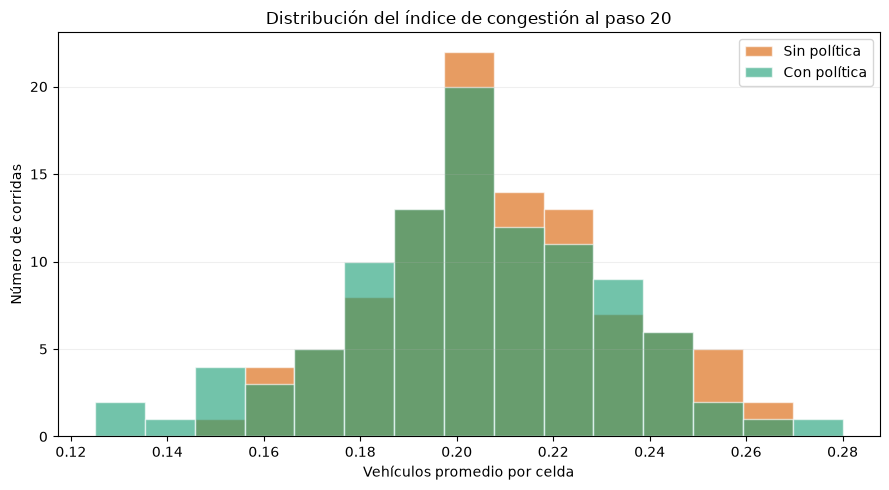

Corridas sin política: 100
Corridas con política: 100


In [13]:
# S8 - Agent Based Modeling P2 - slide 9
Y_without_policy = np.array([
    run_simulation(False, seed) for seed in SCENARIO_SEEDS
])
Y_with_policy = np.array([
    run_simulation(True, seed) for seed in SCENARIO_SEEDS
])

all_results = np.concatenate([Y_without_policy, Y_with_policy])
bins = np.linspace(all_results.min(), all_results.max(), 16)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(
    Y_without_policy,
    bins=bins,
    alpha=0.62,
    color="#d95f02",
    edgecolor="white",
    label="Sin política",
)
ax.hist(
    Y_with_policy,
    bins=bins,
    alpha=0.62,
    color="#1b9e77",
    edgecolor="white",
    label="Con política",
)
ax.set(
    title="Distribución del índice de congestión al paso 20",
    xlabel="Vehículos promedio por celda",
    ylabel="Número de corridas",
)
ax.legend()
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Corridas sin política: {len(Y_without_policy)}")
print(f"Corridas con política: {len(Y_with_policy)}")

## Task 2.1.c - Media, desviación, coeficiente de variación y corridas mínimas

Para cada escenario se calculan la media, la desviación estándary el coeficiente de variacio.

Con 95% de confianza y error relativo tolerado $r=0.05$.

$$M^*=\left\lceil\left(\frac{z_{0.975}CV}{r}\right)^2\right\rceil,\qquad z_{0.975}=1.96.$$

Esta expresión exige más corridas cuando la variabilidad relativa del resultado es mayor.

In [15]:
# S8 - Agent Based Modeling P2 - slide 9
# S8 - Agent Based Modeling P2 - slide 11
def descriptive_statistics(values, relative_error=0.05, z_value=1.96):
    sample_mean = float(np.mean(values))
    sample_std = float(np.std(values, ddof=1))
    coefficient_variation = sample_std / sample_mean
    minimum_runs = int(np.ceil((z_value * coefficient_variation / relative_error) ** 2))
    return {
        "mean": sample_mean,
        "std": sample_std,
        "cv": coefficient_variation,
        "minimum_runs": minimum_runs,
    }


stats_without = descriptive_statistics(Y_without_policy)
stats_with = descriptive_statistics(Y_with_policy)

print(f"{'Escenario':<18} {'Media':>10} {'Desv. est.':>12} {'CV':>10} {'M*':>8}")
print("-" * 62)
for label, stats in [
    ("Sin política", stats_without),
    ("Con política", stats_with),
]:
    print(
        f"{label:<18} {stats['mean']:>10.6f} {stats['std']:>12.6f} "
        f"{stats['cv']:>10.4f} {stats['minimum_runs']:>8d}"
    )


print(
    f"En las 400 celdas, las medias equivalen a "
    f"{stats_without['mean'] * GRID_CELLS:.2f} vehículos sin política y "
    f"{stats_with['mean'] * GRID_CELLS:.2f} con política al paso 20."
)

Escenario               Media   Desv. est.         CV       M*
--------------------------------------------------------------
Sin política         0.207875     0.024617     0.1184       22
Con política         0.203500     0.028531     0.1402       31
En las 400 celdas, las medias equivalen a 83.15 vehículos sin política y 81.40 con política al paso 20.


## Task 2.2.a - Bootstrap de la media

Para un arreglo de $M=100$ resultados se toman $B=2000$ muestras de tamaño 100 con reemplazo. La media de cada remuestra forma la distribución bootstrap. Se reportan su media, su desviación estándar como error estándar bootstrap y los percentiles 2.5 y 97.5 como intervalo de confianza del 95%.

In [16]:
# S8 - Agent Based Modeling P2 - slide 10
def bootstrap_mean(values, B=BOOTSTRAP_RESAMPLES, seed=0):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(B, len(values)))
    bootstrap_means = values[indices].mean(axis=1)
    return {
        "bootstrap_mean": float(bootstrap_means.mean()),
        "bootstrap_se": float(bootstrap_means.std(ddof=1)),
        "ci_95": np.percentile(bootstrap_means, [2.5, 97.5]),
        "replicates": bootstrap_means,
    }


bootstrap_without = bootstrap_mean(Y_without_policy, seed=11_001)
bootstrap_with = bootstrap_mean(Y_with_policy, seed=12_001)

print(f"{'Escenario':<18} {'Media boot':>12} {'EE boot':>12} {'IC 95% percentil':>27}")
print("-" * 74)
for label, result in [
    ("Sin política", bootstrap_without),
    ("Con política", bootstrap_with),
]:
    low, high = result["ci_95"]
    print(
        f"{label:<18} {result['bootstrap_mean']:>12.6f} "
        f"{result['bootstrap_se']:>12.6f} [{low:.6f}, {high:.6f}]"
    )

Escenario            Media boot      EE boot            IC 95% percentil
--------------------------------------------------------------------------
Sin política           0.207863     0.002453 [0.203174, 0.212576]
Con política           0.203547     0.002857 [0.197749, 0.209000]


## Task 2.2.b - Convergencia del error estándar bootstrap

Se repite el bootstrap sobre prefijos acumulados de las corridas: 10, 20, ..., 100. Cada punto usa 2,000 remuestras y una semilla reproducible. 

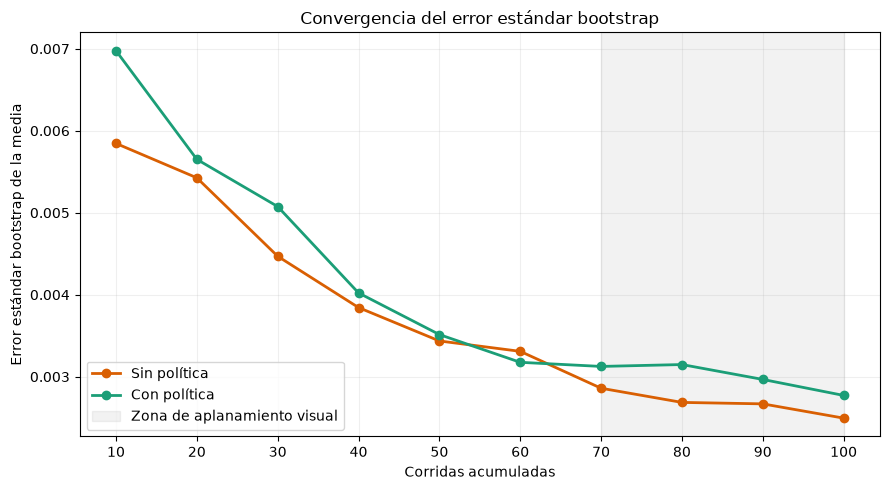

   M      EE sin política      EE con política
------------------------------------------------
  10             0.005845             0.006976
  20             0.005426             0.005651
  30             0.004469             0.005075
  40             0.003843             0.004022
  50             0.003436             0.003514
  60             0.003309             0.003176
  70             0.002860             0.003125
  80             0.002687             0.003148
  90             0.002669             0.002967
 100             0.002495             0.002772


In [17]:
# S8 - Agent Based Modeling P2 - slide 11
accumulated_runs = np.arange(10, 101, 10)
bootstrap_se_without = []
bootstrap_se_with = []

for m in accumulated_runs:
    bootstrap_se_without.append(
        bootstrap_mean(Y_without_policy[:m], seed=10_000 + int(m))["bootstrap_se"]
    )
    bootstrap_se_with.append(
        bootstrap_mean(Y_with_policy[:m], seed=20_000 + int(m))["bootstrap_se"]
    )

bootstrap_se_without = np.asarray(bootstrap_se_without)
bootstrap_se_with = np.asarray(bootstrap_se_with)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    accumulated_runs,
    bootstrap_se_without,
    marker="o",
    linewidth=2,
    color="#d95f02",
    label="Sin política",
)
ax.plot(
    accumulated_runs,
    bootstrap_se_with,
    marker="o",
    linewidth=2,
    color="#1b9e77",
    label="Con política",
)
ax.axvspan(70, 100, color="gray", alpha=0.10, label="Zona de aplanamiento visual")
ax.set(
    title="Convergencia del error estándar bootstrap",
    xlabel="Corridas acumuladas",
    ylabel="Error estándar bootstrap de la media",
    xticks=accumulated_runs,
)
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"{'M':>4} {'EE sin política':>20} {'EE con política':>20}")
print("-" * 48)
for m, se_without, se_with in zip(
    accumulated_runs, bootstrap_se_without, bootstrap_se_with
):
    print(f"{m:>4d} {se_without:>20.6f} {se_with:>20.6f}")

## Task 2.2.c - Diferencia de congestión entre escenarios

Se define $\Delta Y=Y_{\text{sin política}}-Y_{\text{con política}}$. Un valor positivo favorece la política. Como las corridas están emparejadas por semilla, el bootstrap remuestrea las 100 diferencias emparejadas; esto conserva en cada remuestra la heterogeneidad inicial compartida por la pareja de escenarios.

In [19]:
# S8 - Agent Based Modeling P2 - slide 10
paired_differences = Y_without_policy - Y_with_policy
bootstrap_difference = bootstrap_mean(paired_differences, seed=30_000)

delta_estimate = float(paired_differences.mean())
delta_low, delta_high = bootstrap_difference["ci_95"]
interval_includes_zero = bool(delta_low <= 0 <= delta_high)

print(f"Estimación de la diferencia: {delta_estimate:.6f} vehículos/celda")
print(
    f"Media bootstrap de la diferencia: "
    f"{bootstrap_difference['bootstrap_mean']:.6f} vehículos/celda"
)
print(
    f"Error estándar bootstrap: "
    f"{bootstrap_difference['bootstrap_se']:.6f} vehículos/celda"
)
print(f"IC bootstrap 95%: [{delta_low:.6f}, {delta_high:.6f}]")
print("El intervalo incluye cero:", "SÍ" if interval_includes_zero else "NO")
print()
print(
    f"Equivalente en las 400 celdas: estimación = "
    f"{delta_estimate * GRID_CELLS:.2f} vehículos; IC = "
    f"[{delta_low * GRID_CELLS:.2f}, {delta_high * GRID_CELLS:.2f}]."
)


Estimación de la diferencia: 0.004375 vehículos/celda
Media bootstrap de la diferencia: 0.004332 vehículos/celda
Error estándar bootstrap: 0.003076 vehículos/celda
IC bootstrap 95%: [-0.001900, 0.010352]
El intervalo incluye cero: SÍ

Equivalente en las 400 celdas: estimación = 1.75 vehículos; IC = [-0.76, 4.14].
